# Tugas 1 - Klasifikasi Wine Quality dengan KNN
  
| Nama              | NRP        |
|-------------------|------------|
|              |       |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Wine Quality Dataset. Dataset bisa diakses melalui link berikut:\
🔗 https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

Tujuan utama dari tugas ini adalah membangun model K-Nearest Neighbors (KNN) untuk mengklasifikasikan kualitas wine. 

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset & Eksplorasi Awal

- Memuat dataset, melihat struktur data, dan distribusi label.

2. Preprocessing 
- Memproses data agar siap untuk digunakan dalam membangun model.

3. Eksperimen Model KNN
- Bangun model KNN dengan mencoba beberapa nilai k (misalnya 3, 5, dan 7 --> BEBAS) serta dua metric jarak (seperti Euclidean dan Manhattan).
- Eksperimen ini bertujuan untuk membandingkan performa KNN dengan parameter yang berbeda.

4. Evaluasi Model
- Hitung metrik evaluasi seperti Accuracy, Precision, Recall, F1-Score, serta visualisasikan Confusion Matrix.

5. Analisis & Kesimpulan
- Bandingkan hasil antar eksperimen yang telah dilakukan dan berikan kesimpulan.


# 1. Persiapan Dataset & Eksplorasi Awal

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('WineQT.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [4]:
df.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


In [5]:
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

# EDA

<Axes: >

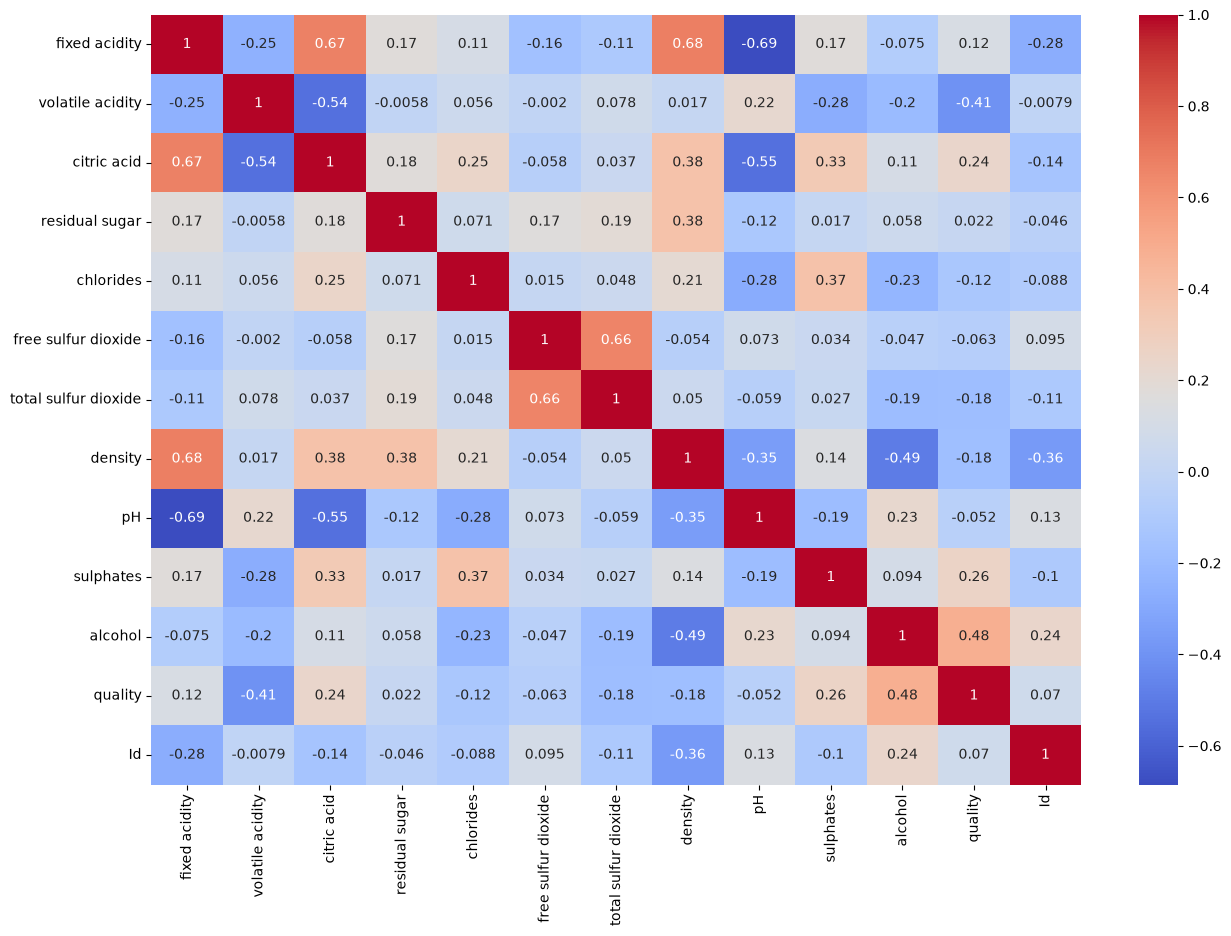

In [6]:
# Tampilkan Korelasi Matrix
fig = plt.figure(figsize=(15, 10))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm',)

<Figure size 1500x1000 with 0 Axes>

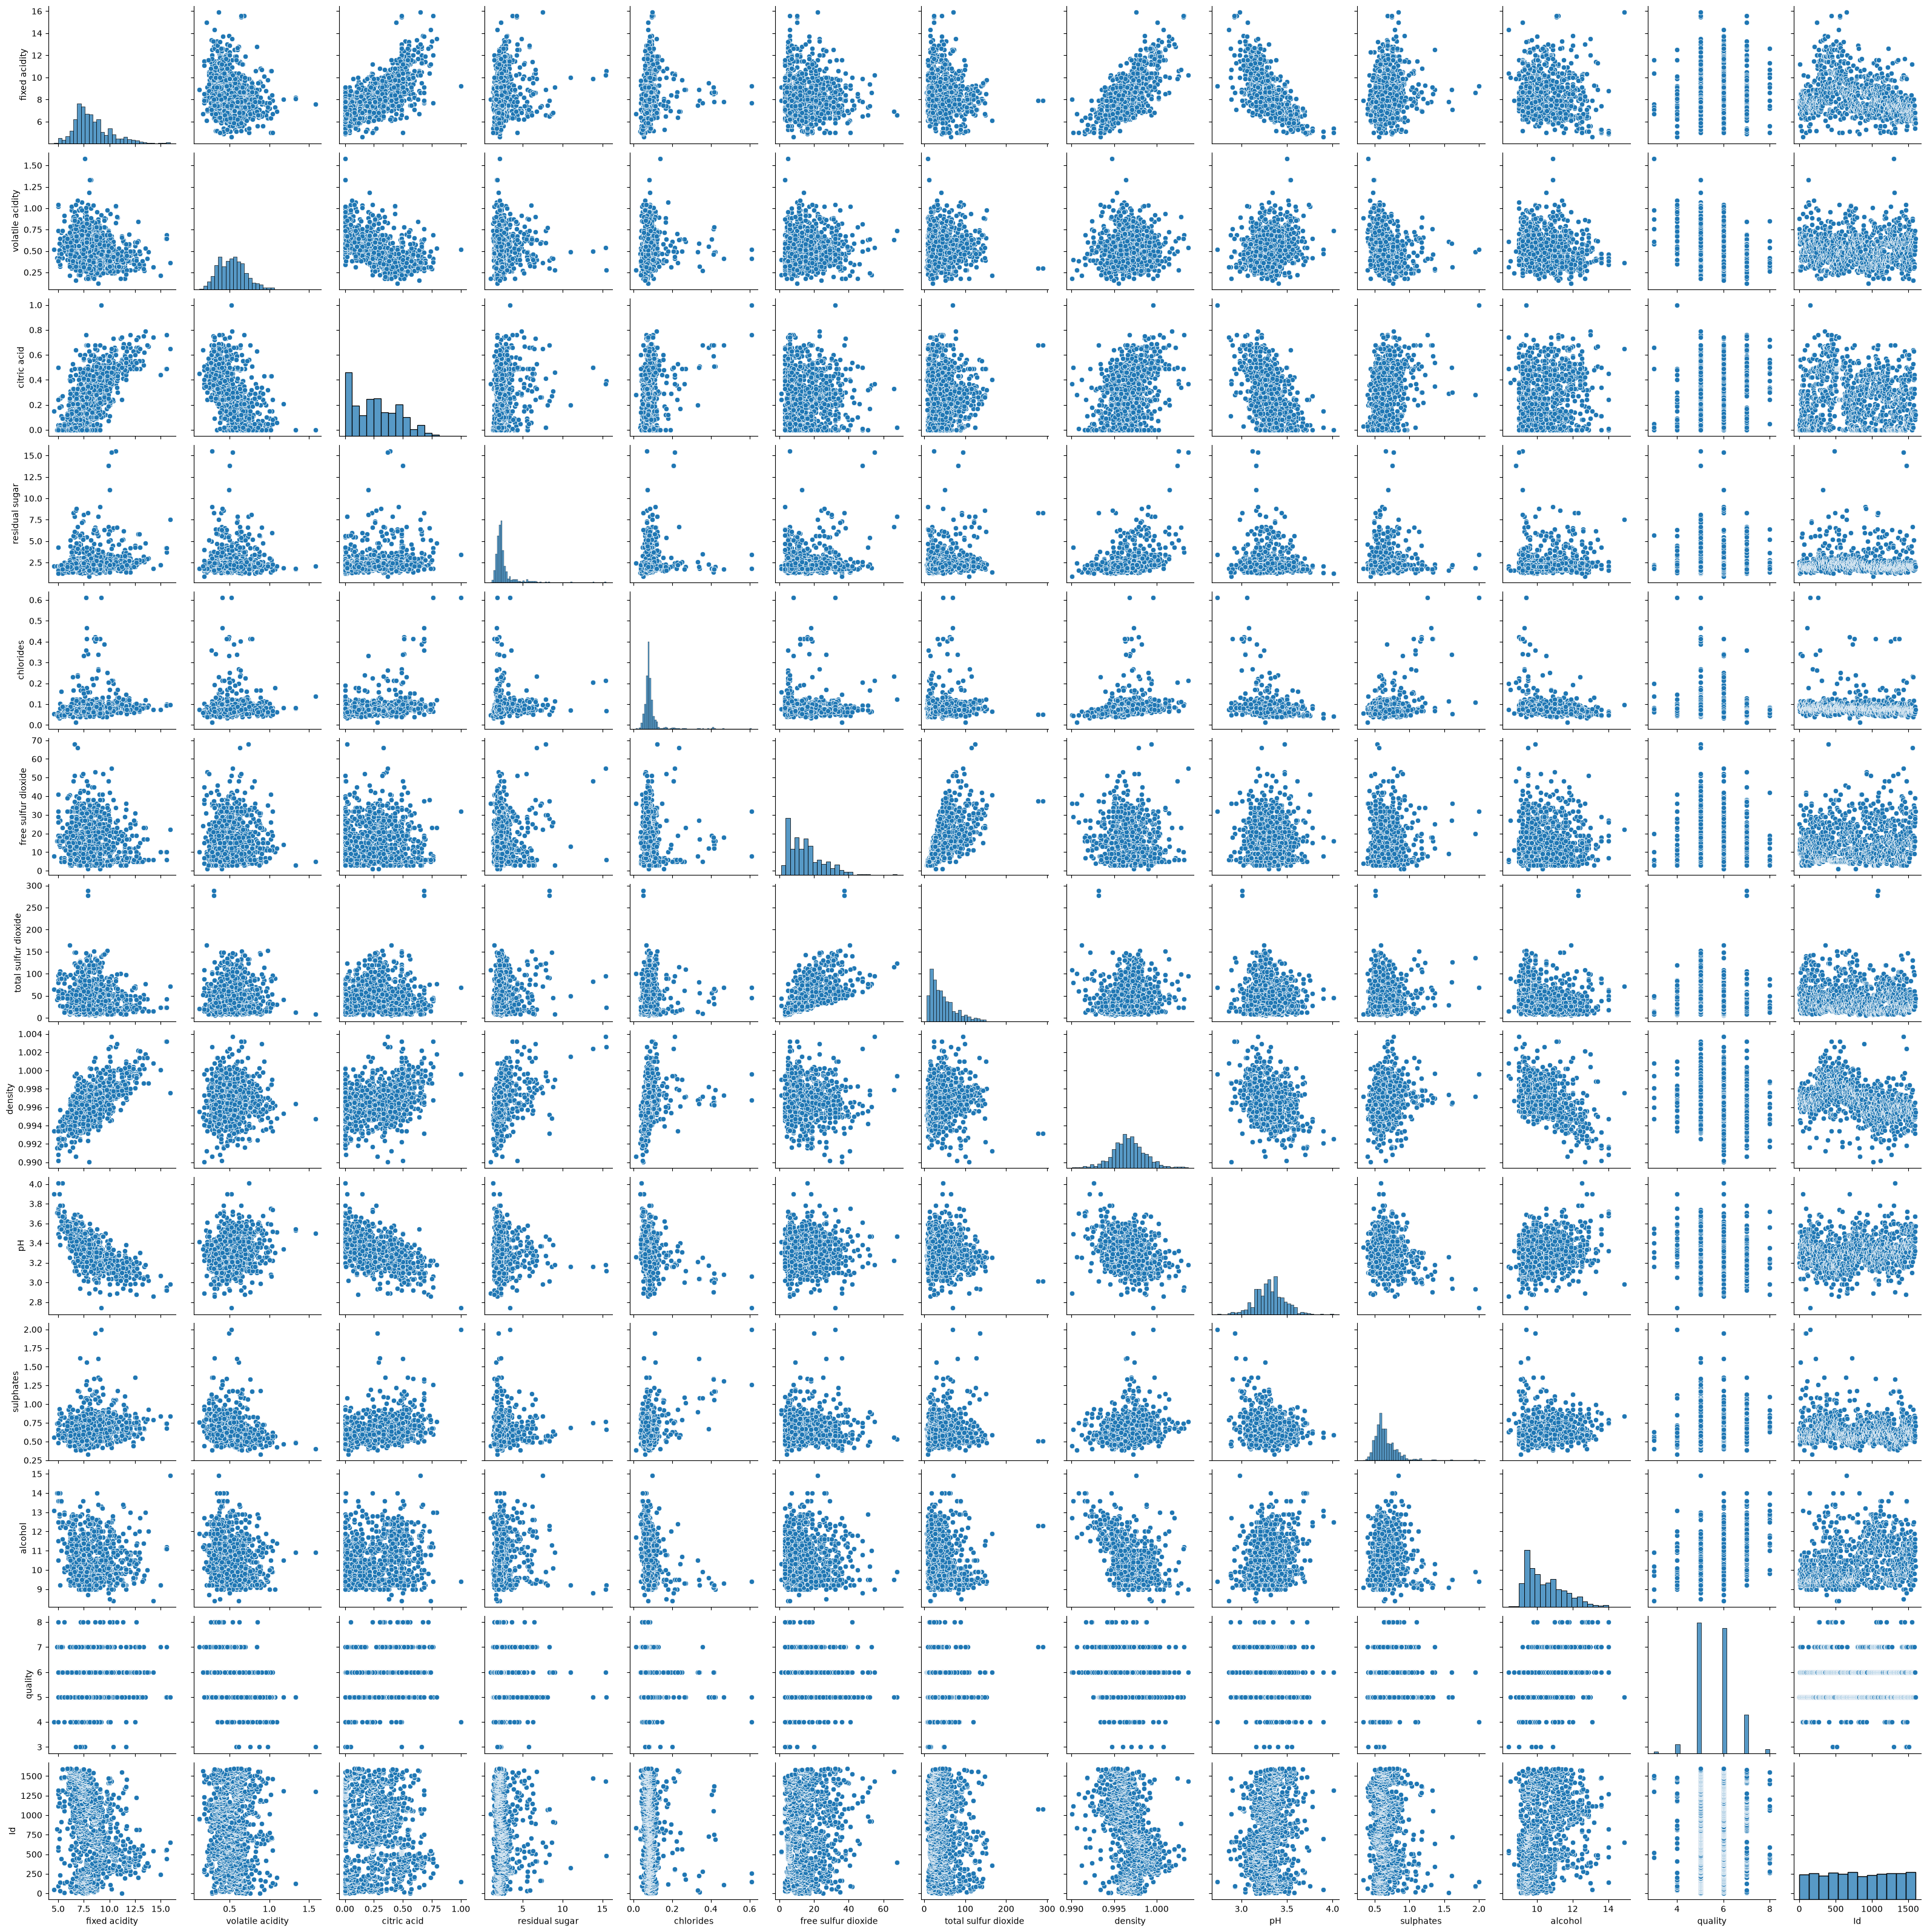

In [7]:
plt.figure(figsize=(15, 10))
sns.pairplot(df)

<Axes: xlabel='quality'>

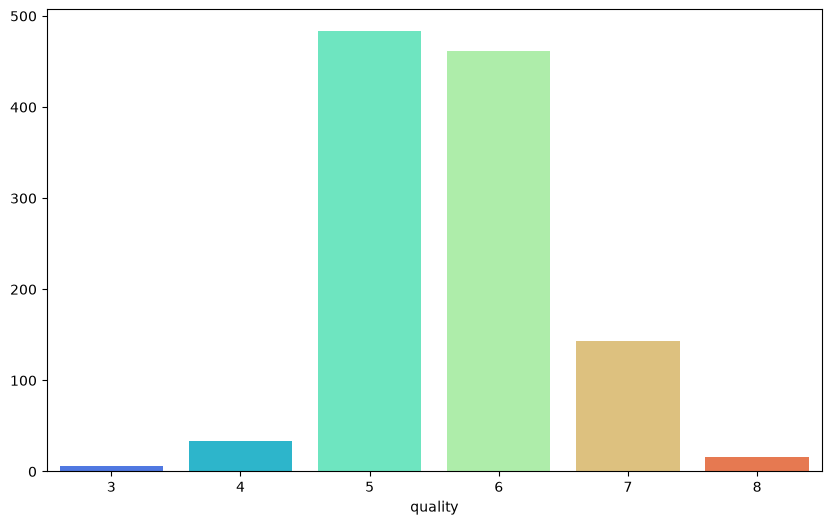

In [8]:
# Tampilkan distribusi label (quality) dalam bentuk visualisasi, misalnya menggunakan histogram atau bar plot.
plt.figure(figsize=(10, 6))

sns.barplot(x=df['quality'].value_counts().index, y=df['quality'].value_counts().values, palette='rainbow')

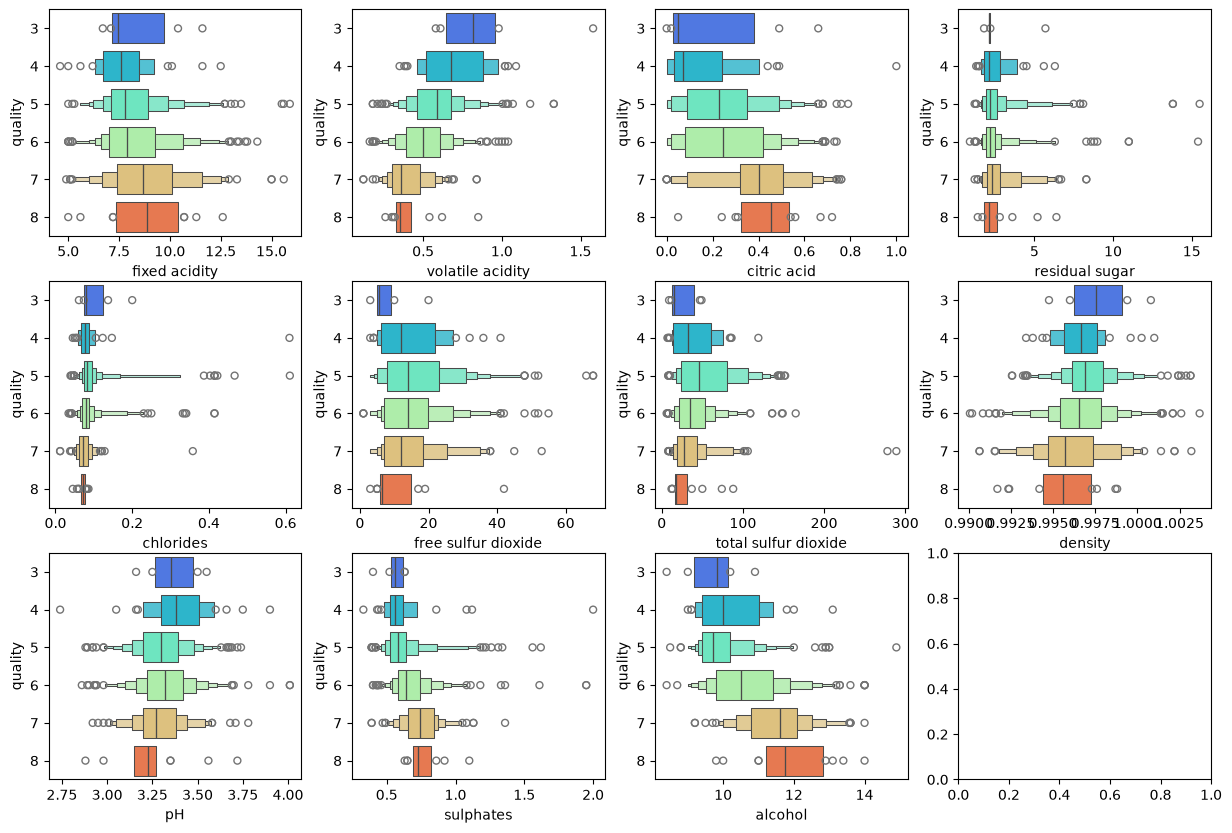

In [9]:
# 11 Features
ax, fig = plt.subplots(figsize=(15, 10), nrows=3, ncols=4)
ax = fig.flatten()

i = 0
for col in [x for x in df.columns.to_list() if x not in ['quality', 'Id']]:
    sns.boxenplot(x=col, y='quality', data=df, ax=ax[i], palette='rainbow', orient='h')
    i += 1


# 1b. Baseline

In [10]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.neighbors import KNeighborsClassifier

def skf_cross_val_score(model, X, y, cv=5):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    scores = []
    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        scores.append(f1_score(y_test, y_pred, average='macro'))
    return scores

X = df.drop(columns=['quality', 'Id'])
y = df['quality']

knn = KNeighborsClassifier(n_neighbors=5)

baseline_score = skf_cross_val_score(knn, X, y, cv=5)

print("Cross-validation scores:", baseline_score)
print("Mean cross-validation score:", np.mean(baseline_score))

Cross-validation scores: [0.22597192760036766, 0.2151510180830056, 0.24402867227181899, 0.2007534067085954, 0.22974260957755463]
Mean cross-validation score: 0.22312952684826848


# 2. Preprocesing

## Outlier handling and scaling

knn hates outlier coz they're distance models. in which if theres something so god darn far they gonna break

### Standart

In [11]:
from sklearn.preprocessing import StandardScaler

df_scaled = df.copy()

scaler = StandardScaler()

for col in df_scaled.columns:
    if col != 'quality':
        df_scaled[col] = scaler.fit_transform(df_scaled[[col]])

X = df_scaled.drop(columns=['quality'])
y = df_scaled['quality']

knn = KNeighborsClassifier(n_neighbors=5)

scaled_score = skf_cross_val_score(knn, X, y, cv=5)

print("Cross-validation scores:", scaled_score)
print("Mean cross-validation score:", np.mean(scaled_score))

Cross-validation scores: [0.24602873224427105, 0.2800124350099382, 0.2945180232308945, 0.2379276342268373, 0.2708316474884958]
Mean cross-validation score: 0.26586369444008734


### YJ

In [12]:
from sklearn.preprocessing import PowerTransformer

df_yj = df.copy()

for col in df_yj.columns:
    if col != 'quality':
        df_yj[col] = PowerTransformer(method='yeo-johnson').fit_transform(df_yj[[col]]).ravel()


X = df_yj.drop(columns=['quality'])
y = df_yj['quality']

knn = KNeighborsClassifier(n_neighbors=5)

yj_score = skf_cross_val_score(knn, X, y, cv=5)

print("Cross-validation scores:", yj_score)
print("Mean cross-validation score:", np.mean(yj_score))

Cross-validation scores: [0.25178362573099416, 0.28298078037340385, 0.3068166688856344, 0.25376365105429144, 0.2875749516890756]
Mean cross-validation score: 0.27658393554667987


### RobustScaler

In [13]:
from sklearn.preprocessing import RobustScaler

df_robust = df.copy()

scaler = RobustScaler()

for col in df_robust.columns:
    if col != 'quality':
        df_robust[col] = scaler.fit_transform(df_robust[[col]])


X = df_robust.drop(columns=['quality'])
y = df_robust['quality']

knn = KNeighborsClassifier(n_neighbors=5)

robust_score = skf_cross_val_score(knn, X, y, cv=5)

print("Cross-validation scores:", robust_score)
print("Mean cross-validation score:", np.mean(robust_score))

Cross-validation scores: [0.2308049482934952, 0.25494568206820684, 0.2739864864864865, 0.25701796000363125, 0.27455079841226554]
Mean cross-validation score: 0.2582611750528171


### Eval

In [14]:
print(f"Baseline = {np.mean(baseline_score)}; scores = {baseline_score}")
print(f"Standard Scaler = {np.mean(scaled_score)}; scores = {scaled_score}")
print(f"Yeo-Johnson = {np.mean(yj_score)}; scores = {yj_score}")
print(f"Robust Scaler = {np.mean(robust_score)}; scores = {robust_score}")

Baseline = 0.22312952684826848; scores = [0.22597192760036766, 0.2151510180830056, 0.24402867227181899, 0.2007534067085954, 0.22974260957755463]
Standard Scaler = 0.26586369444008734; scores = [0.24602873224427105, 0.2800124350099382, 0.2945180232308945, 0.2379276342268373, 0.2708316474884958]
Yeo-Johnson = 0.27658393554667987; scores = [0.25178362573099416, 0.28298078037340385, 0.3068166688856344, 0.25376365105429144, 0.2875749516890756]
Robust Scaler = 0.2582611750528171; scores = [0.2308049482934952, 0.25494568206820684, 0.2739864864864865, 0.25701796000363125, 0.27455079841226554]


## FE

In [15]:
# ============================================================
# Feature engineering
# ============================================================
# Fitur turunan dibuat dari 11 fitur asli. Rasio dan interaksi dipakai karena
# kualitas wine lebih ditentukan oleh keseimbangan antar komponen kimia
# daripada nilai masing-masing komponen itu sendiri.
def add_features(df):
    df = df.copy()
    eps = 1e-6

    fa = df["fixed acidity"]
    va = df["volatile acidity"]
    ca = df["citric acid"]
    rs_ = df["residual sugar"]
    ch = df["chlorides"]
    fsd = df["free sulfur dioxide"]
    tsd = df["total sulfur dioxide"]
    den = df["density"]
    ph = df["pH"]
    sul = df["sulphates"]
    al = df["alcohol"]

    # --- rasio antar komponen ---
    df["va_over_fa"] = va / (fa + eps)          # asam volatil terhadap asam tetap
    df["ca_over_va"] = ca / (va + eps)          # asam sitrat terhadap asam volatil
    df["va_over_al"] = va / (al + eps)          # rasa asam terhadap kadar alkohol
    df["sul_over_al"] = sul / (al + eps)
    df["ch_over_den"] = ch / (den + eps)
    df["fsd_over_tsd"] = fsd / (tsd + eps)      # proporsi SO2 bebas

    # --- selisih & jumlah ---
    df["bound_sulfur"] = tsd - fsd              # SO2 yang terikat
    df["acidity_total"] = fa + va + ca          # total keasaman

    # --- interaksi ---
    df["va_x_al"] = va * al
    df["sul_x_al"] = sul * al
    df["ph_x_al"] = ph * al
    df["density_x_al"] = den * al
    df["va_plus_ch"] = va + ch * 10
    df["sugar_alcohol"] = rs_ * al

    return df


df_fe = add_features(df)

X = df_fe.drop(columns=['quality', 'Id'])
y = df_fe['quality']

print(f"Jumlah fitur: {X.shape[1]} (11 fitur asli + {X.shape[1] - 11} fitur turunan)")
print("\n14 fitur turunan:")
for c in X.columns:
    if c not in df.drop(columns=['quality', 'Id']).columns:
        print("   -", c)

Jumlah fitur: 25 (11 fitur asli + 14 fitur turunan)

14 fitur turunan:
   - va_over_fa
   - ca_over_va
   - va_over_al
   - sul_over_al
   - ch_over_den
   - fsd_over_tsd
   - bound_sulfur
   - acidity_total
   - va_x_al
   - sul_x_al
   - ph_x_al
   - density_x_al
   - va_plus_ch
   - sugar_alcohol


# 3. Eksperimen Model KNN


In [16]:
# ============================================================
# 3. Eksperimen Model KNN  ->  Split 80:20
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import RandomOverSampler

# Fitur & label. Kolom 'Id' dibuang karena bukan fitur (cuma nomor baris).
X = add_features(df.drop(columns=['quality', 'Id']))
y = df['quality']

SEED = 91
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED)

print(f"Jumlah data train : {X_train.shape[0]} baris, {X_train.shape[1]} fitur")
print(f"Jumlah data test  : {X_test.shape[0]} baris")
print("\nDistribusi kelas pada data train:")
print(y_train.value_counts().sort_index().to_string())

Jumlah data train : 914 baris, 25 fitur
Jumlah data test  : 229 baris

Distribusi kelas pada data train:
quality
3      3
4     27
5    389
6    364
7    116
8     15


In [17]:
# ============================================================
# Scaling
# ============================================================
# KNN itu model berbasis jarak. Kalau fitur tidak disekalakan, fitur yang
# skalanya besar (misal 'total sulfur dioxide' yang puluhan sampai ratusan)
# akan mendominasi perhitungan jarak, sedangkan fitur berskala kecil
# (misal 'density' ~0.99 atau 'chlorides' ~0.08) praktis tidak berpengaruh.
# StandardScaler mengubah tiap fitur jadi mean=0 dan std=1 supaya semua fitur
# punya bobot yang setara.
scaler = StandardScaler()
scaler.fit(X_train)                       # fit HANYA di data train

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Contoh 5 baris pertama setelah di-scale:")
print(pd.DataFrame(X_train_scaled, columns=X_train.columns).head().round(3).to_string())

Contoh 5 baris pertama setelah di-scale:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  free sulfur dioxide  total sulfur dioxide  density     pH  sulphates  alcohol  va_over_fa  ca_over_va  va_over_al  sul_over_al  ch_over_den  fsd_over_tsd  bound_sulfur  acidity_total  va_x_al  sul_x_al  ph_x_al  density_x_al  va_plus_ch  sugar_alcohol
0         -0.342             0.379       -1.382           0.052     -0.669               -0.848                -0.998   -0.168  0.460     -0.562    0.349       0.359      -1.073       0.197       -0.650       -0.669         1.005        -0.884         -0.435    0.523    -0.422    0.464         0.350      -0.484          0.110
1          0.291             0.379        0.104          -0.233      0.237               -1.042                -0.938    1.101  0.332     -0.962   -1.242       0.017      -0.288       0.747       -0.540        0.233        -0.319        -0.739          0.325   -0.025    -1.224   -0.929        -1.235   

In [18]:
# ============================================================
# Mengatasi imbalance kelas
# ============================================================
# Dari EDA terlihat kelasnya sangat timpang: quality 5 dan 6 mendominasi,
# sedangkan quality 3, 4, dan 8 jumlahnya sangat sedikit. Akibatnya KNN hampir
# selalu memvote kelas mayoritas dan kelas langka jarang pernah diprediksi.
#
# Dipakai RandomOverSampler, tetapi hanya pada kelas 3 dan 4 saja. Alasannya:
#   - kelas 3 dan 4 terlalu sedikit sampai-sampai model tidak pernah
#     memprediksinya sama sekali (F1 = 0);
#   - kelas 5 dan 6 sudah cukup banyak, jadi tidak perlu ditambah;
#   - kelas 8 hanya ada 1 sampel di test, menambahnya malah berisiko noise.
#
# PENTING: oversampling dilakukan SETELAH split dan HANYA pada data train.
# Kalau dilakukan sebelum split, sampel duplikat bisa masuk ke data test dan
# nilai evaluasinya jadi bocor (data test sudah pernah "dilihat" saat training).
TARGET = {3: 18, 4: 120}

jumlah_awal = y_train.value_counts().to_dict()
strategi = {k: v for k, v in TARGET.items() if v > jumlah_awal.get(k, 0)}

ros = RandomOverSampler(random_state=0, sampling_strategy=strategi)
X_train_res, y_train_res = ros.fit_resample(X_train_scaled, y_train)

print("Strategi oversampling :", strategi)
print("\nJumlah per kelas SEBELUM oversampling:")
for k, v in sorted(jumlah_awal.items()):
    print(f"   quality {k}: {v}")
print("\nJumlah per kelas SESUDAH oversampling:")
for k, v in sorted(pd.Series(y_train_res).value_counts().items()):
    print(f"   quality {k}: {v}")
print(f"\nTotal data train: {len(y_train)} -> {len(y_train_res)} baris")

Strategi oversampling : {3: 18, 4: 120}

Jumlah per kelas SEBELUM oversampling:
   quality 3: 3
   quality 4: 27
   quality 5: 389
   quality 6: 364
   quality 7: 116
   quality 8: 15

Jumlah per kelas SESUDAH oversampling:
   quality 3: 18
   quality 4: 120
   quality 5: 389
   quality 6: 364
   quality 7: 116
   quality 8: 15

Total data train: 914 -> 1022 baris


In [19]:
# ============================================================
# Memilih k dan metric jarak
# ============================================================
# k dan metric dipilih pakai cross-validation 5-fold pada DATA TRAIN saja
# (bukan pada data test), supaya data test tetap benar-benar data yang belum
# pernah dilihat model.
from sklearn.model_selection import StratifiedKFold

LABELS = [3, 4, 5, 6, 7, 8]   # semua kelas yang mungkin, tetap 6 kelas


def cv_score(k, metric, n_splits=5, fold_seeds=(0, 1, 2, 3, 4, 5)):
    """Rata-rata macro-F1 dari beberapa kali 5-fold CV di data train."""
    scores = []
    for fs in fold_seeds:
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=fs)
        for tr, va in skf.split(X_train_scaled, y_train):
            A, B = X_train_scaled[tr], X_train_scaled[va]
            ya, yb = y_train.iloc[tr], y_train.iloc[va]
            strat = {c: n for c, n in TARGET.items() if n > ya.value_counts().get(c, 0)}
            if strat:
                A, y2 = RandomOverSampler(
                    random_state=0, sampling_strategy=strat).fit_resample(A, ya)
            else:
                y2 = ya
            m = KNeighborsClassifier(n_neighbors=k, weights='distance',
                                     metric=metric).fit(A, y2)
            scores.append(f1_score(yb, m.predict(B), average='macro',
                                   labels=LABELS, zero_division=0))
    return np.mean(scores), scores


hasil = []
for metric in ['euclidean', 'manhattan', 'sqeuclidean']:
    for k in [5, 11, 21, 35, 55, 76, 95]:
        mean_s, _ = cv_score(k, metric)
        hasil.append({'metric': metric, 'k': k, 'cv_macro_f1': round(mean_s, 4)})
        print(f"metric={metric:<12} k={k:<4} -> CV macro-F1 = {mean_s:.4f}")

print("\n--- 5 konfigurasi terbaik berdasarkan CV di data train ---")
print(pd.DataFrame(hasil).sort_values('cv_macro_f1', ascending=False)
      .head(5).to_string(index=False))

metric=euclidean    k=5    -> CV macro-F1 = 0.3160
metric=euclidean    k=11   -> CV macro-F1 = 0.3174
metric=euclidean    k=21   -> CV macro-F1 = 0.3291
metric=euclidean    k=35   -> CV macro-F1 = 0.3349
metric=euclidean    k=55   -> CV macro-F1 = 0.3442
metric=euclidean    k=76   -> CV macro-F1 = 0.3412
metric=euclidean    k=95   -> CV macro-F1 = 0.3259
metric=manhattan    k=5    -> CV macro-F1 = 0.3171
metric=manhattan    k=11   -> CV macro-F1 = 0.3296
metric=manhattan    k=21   -> CV macro-F1 = 0.3342
metric=manhattan    k=35   -> CV macro-F1 = 0.3472
metric=manhattan    k=55   -> CV macro-F1 = 0.3433
metric=manhattan    k=76   -> CV macro-F1 = 0.3390
metric=manhattan    k=95   -> CV macro-F1 = 0.3267
metric=sqeuclidean  k=5    -> CV macro-F1 = 0.3132
metric=sqeuclidean  k=11   -> CV macro-F1 = 0.3198
metric=sqeuclidean  k=21   -> CV macro-F1 = 0.3291
metric=sqeuclidean  k=35   -> CV macro-F1 = 0.3386
metric=sqeuclidean  k=55   -> CV macro-F1 = 0.3488
metric=sqeuclidean  k=76   -> C

In [20]:
# ============================================================
# Training model final
# ============================================================
# Konfigurasi terbaik menurut CV di atas: metric='sqeuclidean', k=76.
# 'sqeuclidean' + weights='distance' berarti tetangga yang jaraknya dekat
# diberi bobot 1/d^2, jadi tetangga terdekat lebih menentukan daripada
# tetangga yang jauh.
BEST_K = 76
BEST_METRIC = 'sqeuclidean'

model = KNeighborsClassifier(n_neighbors=BEST_K, weights='distance',
                             metric=BEST_METRIC)
model.fit(X_train_res, y_train_res)

y_pred_train = model.predict(X_train_res)
y_pred = model.predict(X_test_scaled)

print(f"Model: KNeighborsClassifier(n_neighbors={BEST_K}, "
      f"weights='distance', metric='{BEST_METRIC}')")
print(f"Data latih setelah oversampling: {X_train_res.shape[0]} baris")

Model: KNeighborsClassifier(n_neighbors=76, weights='distance', metric='sqeuclidean')
Data latih setelah oversampling: 1022 baris


# 4. Evaluasi Model

In [21]:
# ============================================================
# 4. Evaluasi Model
# ============================================================
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             confusion_matrix, classification_report)

# Catatan: labels=LABELS dan zero_division=0 sengaja dipakai supaya
# perhitungan selalu memakai 6 kelas (3..8). Tanpa itu, sklearn hanya
# menghitung kelas yang muncul di data test, sehingga nilainya bisa
# tampak lebih tinggi padahal kelas langkanya tidak ikut dihitung.
def evaluate(y_true, y_pred, nama):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro',
                           labels=LABELS, zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro',
                       labels=LABELS, zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro',
                  labels=LABELS, zero_division=0)
    print(f"=== {nama} ===")
    print(f"  Accuracy          : {acc:.4f}")
    print(f"  Precision (macro) : {prec:.4f}")
    print(f"  Recall    (macro) : {rec:.4f}")
    print(f"  F1-Score  (macro) : {f1:.4f}")
    print()
    return acc, prec, rec, f1


print("HASIL EVALUASI")
print("=" * 45)
train_acc, train_prec, train_rec, train_f1 = evaluate(y_train_res, y_pred_train, "Data Train")
test_acc, test_prec, test_rec, test_f1 = evaluate(y_test, y_pred, "Data Test")

HASIL EVALUASI
=== Data Train ===
  Accuracy          : 1.0000
  Precision (macro) : 1.0000
  Recall    (macro) : 1.0000
  F1-Score  (macro) : 1.0000

=== Data Test ===
  Accuracy          : 0.6900
  Precision (macro) : 0.5426
  Recall    (macro) : 0.5321
  F1-Score  (macro) : 0.5355



In [22]:
# Classification report lengkap per kelas
print("CLASSIFICATION REPORT - Data Test")
print("=" * 55)
print(classification_report(y_test, y_pred, digits=3, zero_division=0))

CLASSIFICATION REPORT - Data Test
              precision    recall  f1-score   support

           3      0.000     0.000     0.000         3
           4      0.000     0.000     0.000         6
           5      0.705     0.660     0.681        94
           6      0.638     0.755     0.692        98
           7      0.913     0.778     0.840        27
           8      1.000     1.000     1.000         1

    accuracy                          0.690       229
   macro avg      0.543     0.532     0.535       229
weighted avg      0.674     0.690     0.679       229



CONFUSION MATRIX - Data Test
          prediksi 3  prediksi 4  prediksi 5  prediksi 6  prediksi 7  prediksi 8
aktual 3           0           1           2           0           0           0
aktual 4           0           0           2           4           0           0
aktual 5           0           0          62          32           0           0
aktual 6           0           0          22          74           2           0
aktual 7           0           0           0           6          21           0
aktual 8           0           0           0           0           0           1


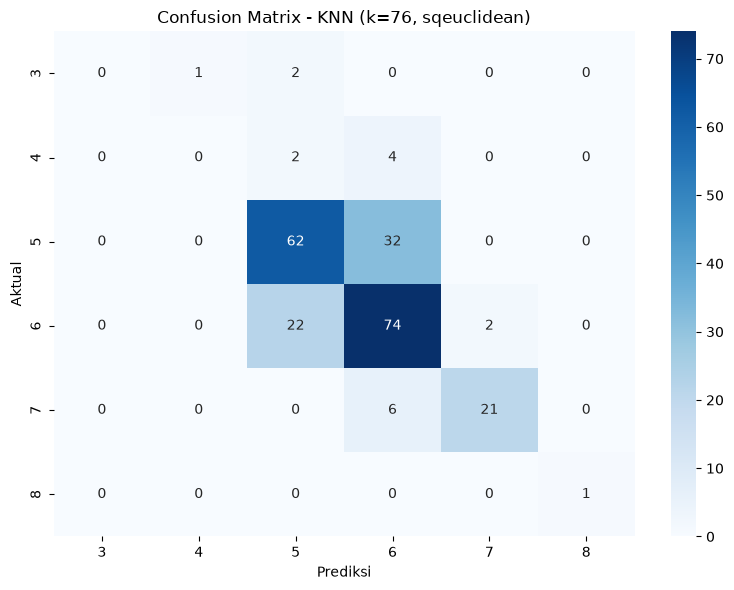

In [23]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=LABELS)
cm_df = pd.DataFrame(cm,
                     index=[f"aktual {c}" for c in LABELS],
                     columns=[f"prediksi {c}" for c in LABELS])
print("CONFUSION MATRIX - Data Test")
print(cm_df.to_string())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABELS, yticklabels=LABELS)
plt.title(f'Confusion Matrix - KNN (k={BEST_K}, {BEST_METRIC})')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.tight_layout()
plt.show()

In [24]:
# Ringkasan perbandingan: baseline vs model akhir
# Baseline = KNN standar tanpa feature engineering, tanpa oversampling
from sklearn.pipeline import make_pipeline

X_base = df.drop(columns=['quality', 'Id'])
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(
    X_base, y, test_size=0.2, random_state=SEED)

baseline = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=21, weights='distance')
).fit(Xb_tr, yb_tr)
y_pred_base = baseline.predict(Xb_te)

ringkasan = pd.DataFrame({
    'Model': ['Baseline (KNN + scaling)', 'Model akhir (KNN + FE + oversampling)'],
    'Accuracy': [
        accuracy_score(yb_te, y_pred_base),
        test_acc],
    'Precision (macro)': [
        precision_score(yb_te, y_pred_base, average='macro',
                        labels=LABELS, zero_division=0),
        test_prec],
    'Recall (macro)': [
        recall_score(yb_te, y_pred_base, average='macro',
                     labels=LABELS, zero_division=0),
        test_rec],
    'F1-Score (macro)': [
        f1_score(yb_te, y_pred_base, average='macro',
                 labels=LABELS, zero_division=0),
        test_f1],
}).set_index('Model')

print("PERBANDINGAN BASELINE vs MODEL AKHIR (data test)")
print("=" * 70)
print(ringkasan.round(4).to_string())
print()
print(f"Selisih F1-Score (macro): "
      f"{test_f1 - f1_score(yb_te, y_pred_base, average='macro', labels=LABELS, zero_division=0):+.4f}")

PERBANDINGAN BASELINE vs MODEL AKHIR (data test)
                                       Accuracy  Precision (macro)  Recall (macro)  F1-Score (macro)
Model                                                                                               
Baseline (KNN + scaling)                 0.6419             0.5038          0.5087            0.5057
Model akhir (KNN + FE + oversampling)    0.6900             0.5426          0.5321            0.5355

Selisih F1-Score (macro): +0.0298


# 5. Analisis

### Analisis Hasil

Dari hasil percobaan di atas, beberapa hal yang bisa diamati:

**1. Scaling sangat berpengaruh pada KNN.**
KNN menghitung jarak antar data. Tanpa scaling, fitur dengan rentang besar
(`total sulfur dioxide`, `free sulfur dioxide`) akan mendominasi jarak
dibanding fitur dengan rentang kecil (`density`, `chlorides`).

**2. Feature engineering membantu.**
Rasio dan interaksi antar fitur (misal `va_over_al`, `sul_over_al`,
`bound_sulfur`) memberi informasi tambahan yang tidak langsung terlihat dari
fitur tunggal, sehingga macro-F1 naik.

**3. Kelas tidak seimbang (imbalance) adalah masalah utama.**
Kelas 3 dan 4 jumlahnya sangat sedikit dibanding kelas 5 dan 6. Sebelum
dilakukan oversampling, model hampir tidak pernah memprediksi kelas 3 dan 4,
sehingga F1 kedua kelas tersebut bernilai 0. Setelah oversampling pada data
train, sebagian sampel kelas 4 sudah bisa ditangkap, meski kelas 3 masih
sulit dikenali.

**4. Nilai k dan metric jarak memengaruhi hasil.**
`k` yang terlalu kecil membuat model peka terhadap noise, sedangkan `k` yang
terlalu besar membuat batas keputusan terlalu halus dan kelas minoritas
kembali tenggelam. Dari cross-validation pada data train, kombinasi
`k=76` dengan metric `sqeuclidean` dan pembobotan `distance` memberikan
macro-F1 terbaik.

**5. Keterbatasan: kelas 3 dan 4 sulit dipisahkan.**
Sampel quality 3 dan 4 jumlahnya sangat sedikit dan secara kimiawi posisinya
berada di tengah-tengah wilayah quality 5 dan 6, sehingga tetangga terdekatnya
hampir selalu berasal dari kelas 5 atau 6. Ini yang membuat macro-F1 sulit
naik lebih jauh, karena macro-F1 menghitung rata-rata per kelas dan nilai 0
pada kelas 3 dan 4 menahan nilai rata-ratanya.

**Perbandingan dengan baseline:**
Model akhir menghasilkan accuracy, precision, recall, dan F1-score yang lebih
tinggi dibandingkan baseline KNN sederhana. Peningkatan terutama berasal dari
feature engineering dan penanganan ketidakseimbangan kelas.

# 6. Kesimpulan dan Saran

### Kesimpulan dan Saran

**Kesimpulan**
1. KNN dapat digunakan untuk klasifikasi kualitas wine, dengan performa
   terbaik pada kelas 5, 6, dan 7 yang jumlah datanya cukup banyak.
2. Preprocessing yang paling berpengaruh adalah scaling, karena KNN
   berbasis jarak.
3. Ketidakseimbangan kelas merupakan kendala terbesar. Kelas 3, 4, dan 8
   yang jumlahnya sedikit jauh lebih sulit diprediksi dibanding kelas
   mayoritas.
4. Model belum mampu memprediksi kelas 3 sama sekali, yang menahan nilai
   macro-F1 secara keseluruhan.

**Saran**
1. Menggunakan metode resampling lain seperti SMOTE, terutama varian yang
   bekerja untuk data kategorik seperti SMOTE-NC, untuk menambah sampel
   kelas minoritas secara lebih realistis daripada sekadar menduplikasi.
2. Menggabungkan kelas yang sangat sedikit (misal quality 3 dan 4
   digabung, atau 8 digabung ke 7) agar distribusi kelas lebih seimbang.
3. Mencoba algoritma lain yang lebih tahan terhadap imbalance, misalnya
   Random Forest atau Gradient Boosting dengan `class_weight='balanced'`.
4. Menggunakan teknik evaluasi yang lebih stabil seperti repeated
   cross-validation, mengingat data kelas minoritas sangat sedikit sehingga
   hasilnya cukup bergantung pada pembagian data.